# Train Houses LoRA

Self-contained LoRA training for `stable-diffusion-v1-5/stable-diffusion-inpainting`.

This notebook does not use the old training script. It reads the prepared dataset from `datasets/houses` and saves website-ready weights to `outputs/lora_houses`.

In [1]:
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "backend").exists() and (candidate / "frontend").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Run this notebook from the repo or notebooks directory.")


REPO_ROOT = find_repo_root()
MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-inpainting"
DATASET_DIR = REPO_ROOT / "datasets" / "houses"
OUTPUT_DIR = REPO_ROOT / "outputs" / "lora_houses"
PREPARE_SCRIPT = REPO_ROOT / "notebooks" / "scripts" / "prepare_morocco_buildings_lora_dataset.py"

INSTANCE_PROMPT = "satellite view of small houses, roof geometry, driveways, residential block"
NEGATIVE_PROMPT = "blurry, distorted, repeated roofs, warped perspective, low quality"

RESOLUTION = 512
TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 1e-4
MAX_TRAIN_STEPS = 1200
CHECKPOINTING_STEPS = 300
RANK = 16
LORA_ALPHA = 16
SEED = 42
LOCAL_FILES_ONLY = True
MIXED_PRECISION = "fp16"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("repo root:", REPO_ROOT)
print("dataset:", DATASET_DIR)
print("output:", OUTPUT_DIR)
print("prepare script:", PREPARE_SCRIPT)


repo root: C:\Users\neman\Documents\UVPython\inpainting
dataset: C:\Users\neman\Documents\UVPython\inpainting\datasets\houses
output: C:\Users\neman\Documents\UVPython\inpainting\outputs\lora_houses
prepare script: C:\Users\neman\Documents\UVPython\inpainting\notebooks\scripts\prepare_morocco_buildings_lora_dataset.py


In [2]:
import json
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from accelerate import Accelerator
from accelerate.utils import ProjectConfiguration, set_seed
from diffusers import AutoencoderKL, DDPMScheduler, StableDiffusionInpaintPipeline, UNet2DConditionModel
from diffusers.optimization import get_scheduler
from diffusers.training_utils import cast_training_params
from diffusers.utils import convert_state_dict_to_diffusers
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF
from transformers import CLIPTextModel, CLIPTokenizer


@dataclass
class Record:
    image_path: Path
    mask_path: Path
    prompt: str


def load_records(dataset_dir: Path, default_prompt: str) -> list[Record]:
    metadata_path = dataset_dir / "metadata.jsonl"
    if not metadata_path.exists():
        raise FileNotFoundError(
            f"Missing dataset metadata: {metadata_path}\n"
            "Prepare it first with:\n"
            f"  cd {REPO_ROOT / 'notebooks'}\n"
            f"  uv run python scripts/{PREPARE_SCRIPT.name} --output-dir ../datasets/{dataset_dir.name}"
        )
    records = []
    for line in metadata_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        row = json.loads(line)
        records.append(Record(dataset_dir / row["image"], dataset_dir / row["mask"], row.get("prompt", default_prompt)))
    if not records:
        raise ValueError(f"No records found in {metadata_path}")
    return records


class InpaintDataset(Dataset):
    def __init__(self, dataset_dir: Path, tokenizer, resolution: int, prompt: str):
        self.records = load_records(dataset_dir, prompt)
        self.tokenizer = tokenizer
        self.resolution = resolution
        self.image_to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.records)

    def preprocess(self, image: Image.Image, mask: Image.Image):
        image = TF.resize(image, self.resolution, interpolation=transforms.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, self.resolution, interpolation=transforms.InterpolationMode.NEAREST)
        top, left, height, width = transforms.RandomCrop.get_params(image, output_size=(self.resolution, self.resolution))
        image = TF.crop(image, top, left, height, width)
        mask = TF.crop(mask, top, left, height, width)
        mask = mask.point(lambda value: 255 if value > 127 else 0)
        return image, mask

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record.image_path).convert("RGB")
        mask = Image.open(record.mask_path).convert("L")
        image, mask = self.preprocess(image, mask)

        image_tensor = self.image_to_tensor(image)
        mask_tensor = (transforms.ToTensor()(mask) > 0.5).float()
        masked_image = image_tensor * (mask_tensor < 0.5)
        input_ids = self.tokenizer(record.prompt, padding="do_not_pad", truncation=True, max_length=self.tokenizer.model_max_length).input_ids
        return {"pixel_values": image_tensor, "mask": mask_tensor, "masked_image": masked_image, "input_ids": input_ids}


def collate_fn(examples, tokenizer):
    return {
        "pixel_values": torch.stack([example["pixel_values"] for example in examples]).contiguous().float(),
        "masks": torch.stack([example["mask"] for example in examples]).contiguous().float(),
        "masked_images": torch.stack([example["masked_image"] for example in examples]).contiguous().float(),
        "input_ids": tokenizer.pad({"input_ids": [example["input_ids"] for example in examples]}, padding=True, return_tensors="pt").input_ids,
    }


def save_lora(unet, output_dir: Path):
    state_dict = get_peft_model_state_dict(unet)
    state_dict = convert_state_dict_to_diffusers(state_dict)
    StableDiffusionInpaintPipeline.save_lora_weights(str(output_dir), unet_lora_layers=state_dict, safe_serialization=True)


records = load_records(DATASET_DIR, INSTANCE_PROMPT)
print("records:", len(records))
print("first image:", records[0].image_path)
print("first mask:", records[0].mask_path)

records: 2536
first image: C:\Users\neman\Documents\UVPython\inpainting\datasets\houses\images\000000.png
first mask: C:\Users\neman\Documents\UVPython\inpainting\datasets\houses\masks\000000_mask.png


mask coverage: 0.039882659912109375


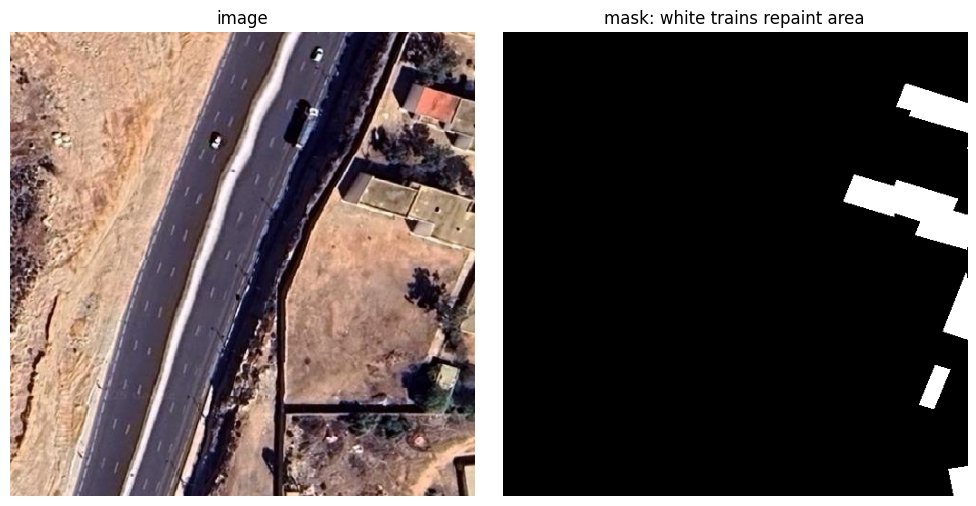

In [3]:
sample_image = Image.open(records[0].image_path).convert("RGB")
sample_mask = Image.open(records[0].mask_path).convert("L")
sample_mask = sample_mask.point(lambda value: 255 if value > 127 else 0)
print("mask coverage:", sum(sample_mask.histogram()[1:]) / (sample_mask.width * sample_mask.height))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_image)
axes[0].set_title("image")
axes[0].axis("off")
axes[1].imshow(sample_mask, cmap="gray")
axes[1].set_title("mask: white trains repaint area")
axes[1].axis("off")
plt.tight_layout()

In [ ]:
set_seed(SEED)

accelerator = Accelerator(
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    mixed_precision=MIXED_PRECISION,
    project_config=ProjectConfiguration(project_dir=str(OUTPUT_DIR), logging_dir=str(OUTPUT_DIR / "logs")),
)

load_kwargs = {"local_files_only": LOCAL_FILES_ONLY}
tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer", **load_kwargs)
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder", **load_kwargs)
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae", **load_kwargs)
unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet", **load_kwargs)
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler", **load_kwargs)

if int(unet.config.in_channels) != 9:
    raise RuntimeError(f"Expected inpainting UNet with 9 channels, got {unet.config.in_channels}")

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)
unet.add_adapter(LoraConfig(r=RANK, lora_alpha=LORA_ALPHA, init_lora_weights="gaussian", target_modules=["to_q", "to_k", "to_v", "to_out.0"]))
unet.enable_gradient_checkpointing()
cast_training_params(unet, dtype=torch.float32)

weight_dtype = torch.float16 if MIXED_PRECISION == "fp16" else torch.float32
vae.to(accelerator.device, dtype=weight_dtype)
text_encoder.to(accelerator.device, dtype=weight_dtype)

dataset = InpaintDataset(DATASET_DIR, tokenizer, RESOLUTION, INSTANCE_PROMPT)
dataloader = DataLoader(dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True, collate_fn=lambda examples: collate_fn(examples, tokenizer))

trainable_params = [parameter for parameter in unet.parameters() if parameter.requires_grad]
print("trainable params:", sum(parameter.numel() for parameter in trainable_params))
optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, betas=(0.9, 0.999), weight_decay=1e-2, eps=1e-8)
lr_scheduler = get_scheduler("constant", optimizer=optimizer, num_warmup_steps=0, num_training_steps=MAX_TRAIN_STEPS)

unet, optimizer, dataloader, lr_scheduler = accelerator.prepare(unet, optimizer, dataloader, lr_scheduler)

global_step = 0
num_epochs = math.ceil(MAX_TRAIN_STEPS / max(1, math.ceil(len(dataloader) / GRADIENT_ACCUMULATION_STEPS)))
for epoch in range(num_epochs):
    unet.train()
    running_loss = 0.0
    for step, batch in enumerate(dataloader):
        with accelerator.accumulate(unet):
            pixel_values = batch["pixel_values"].to(dtype=weight_dtype)
            masks = batch["masks"].to(dtype=weight_dtype)
            masked_images = batch["masked_images"].to(dtype=weight_dtype)
            input_ids = batch["input_ids"].to(accelerator.device)

            latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor
            masked_latents = vae.encode(masked_images).latent_dist.sample() * vae.config.scaling_factor
            mask_latents = F.interpolate(masks, size=latents.shape[-2:])
            noise = torch.randn_like(latents)
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=latents.device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            encoder_hidden_states = text_encoder(input_ids, return_dict=False)[0]
            model_input = torch.cat([noisy_latents, mask_latents, masked_latents], dim=1)
            model_pred = unet(model_input, timesteps, encoder_hidden_states=encoder_hidden_states, return_dict=False)[0]
            loss = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")

            accelerator.backward(loss)
            if accelerator.sync_gradients:
                accelerator.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            running_loss += loss.detach().item()

        if accelerator.sync_gradients:
            global_step += 1
            if global_step % 10 == 0:
                accelerator.print(f"step {global_step}/{MAX_TRAIN_STEPS} loss={running_loss / max(1, step + 1):.4f}")
            if global_step % CHECKPOINTING_STEPS == 0 and accelerator.is_main_process:
                save_lora(accelerator.unwrap_model(unet), OUTPUT_DIR / f"checkpoint-{global_step}")
            if global_step >= MAX_TRAIN_STEPS:
                break
    if global_step >= MAX_TRAIN_STEPS:
        break

accelerator.wait_for_everyone()
if accelerator.is_main_process:
    save_lora(accelerator.unwrap_model(unet), OUTPUT_DIR)
    (OUTPUT_DIR / "training_args.json").write_text(json.dumps({
        "model_id": MODEL_ID,
        "dataset_dir": str(DATASET_DIR),
        "prompt": INSTANCE_PROMPT,
        "resolution": RESOLUTION,
        "max_train_steps": MAX_TRAIN_STEPS,
        "learning_rate": LEARNING_RATE,
        "rank": RANK,
        "lora_alpha": LORA_ALPHA,
        "seed": SEED,
    }, indent=2), encoding="utf-8")
print("saved:", OUTPUT_DIR / "pytorch_lora_weights.safetensors")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: stable-diffusion-v1-5/stable-diffusion-inpainting
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\neman\Documents\UVPython\inpainting\notebooks\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
An error occurred while trying to fetch stable-diffusion-v1-5/stable-diffusion-inpainting: stable-diffusion-v1-5/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying

trainable params: 3188736


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
pipe = StableDiffusionInpaintPipeline.from_pretrained(MODEL_ID, torch_dtype=dtype, safety_checker=None, local_files_only=LOCAL_FILES_ONLY).to(device)
pipe.load_lora_weights(str(OUTPUT_DIR), adapter_name="houses")
pipe.set_adapters(["houses"], adapter_weights=[1.0])
pipe.set_progress_bar_config(disable=False)

test_image = sample_image.resize((RESOLUTION, RESOLUTION), Image.Resampling.BILINEAR)
test_mask = sample_mask.resize((RESOLUTION, RESOLUTION), Image.Resampling.NEAREST)
generator = torch.Generator(device=device).manual_seed(7)
validation = pipe(
    prompt=INSTANCE_PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    image=test_image,
    mask_image=test_mask,
    height=RESOLUTION,
    width=RESOLUTION,
    strength=1.0,
    num_inference_steps=40,
    guidance_scale=4.5,
    generator=generator,
).images[0]
validation.save(OUTPUT_DIR / "validation_lora.png")
validation